In [3]:
import pandas as pd
import numpy as np

In [4]:
sales_df = pd.read_csv("../sales_data.csv")
product_df = pd.read_csv("../product_info.csv")
customer_df = pd.read_csv("../customer_info.csv")

In [5]:
sales_df.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-2025,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-2025,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,07-07-2025,delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,08-07-2025,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,08-07-2025,DELAYED,Credit Card,West,0.20


In [6]:
product_df.head()

,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,11-03-25,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,18-08-24,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,15-07-24,7.92,S745
3,P0004,Kitchen Product 82,Kitchen,19-04-25,9.13,S589
4,P0005,Personal Care Product 1,Personal Care,20-10-24,31.10,S559


In [7]:
customer_df.head()

,customer_id,email,signup_date,gender,region,loyalty_tier
0,C00001,shaneramirez@gmail.com,26-04-25,Male,Central,Silver
1,C00002,jpeterson@bernard.com,11-08-24,Female,Central,gold
2,C00003,howardmaurice@yahoo.com,15-05-25,male,Central,gold
3,C00004,yherrera@arnold.org,14-06-25,FEMALE,Central,GOLD
4,C00005,janetwilliams@gmail.com,02-05-25,Male,West,bronze


In [8]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2999 non-null   object 
 1   customer_id       2998 non-null   object 
 2   product_id        2995 non-null   object 
 3   quantity          2997 non-null   object 
 4   unit_price        2999 non-null   float64
 5   order_date        2998 non-null   object 
 6   delivery_status   2997 non-null   object 
 7   payment_method    2997 non-null   object 
 8   region            3000 non-null   object 
 9   discount_applied  2483 non-null   float64
dtypes: float64(2), object(8)
memory usage: 234.5+ KB


In [9]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     30 non-null     object 
 1   product_name   30 non-null     object 
 2   category       30 non-null     object 
 3   launch_date    30 non-null     object 
 4   base_price     30 non-null     float64
 5   supplier_code  30 non-null     object 
dtypes: float64(1), object(5)
memory usage: 1.5+ KB


In [10]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   497 non-null    object
 1   email         494 non-null    object
 2   signup_date   496 non-null    object
 3   gender        496 non-null    object
 4   region        497 non-null    object
 5   loyalty_tier  498 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


In [11]:
sales_df.shape

(3000, 10)

In [12]:
product_df.shape

(30, 6)

In [13]:
customer_df.shape

(500, 6)

In [14]:
sales_df['quantity'] = pd.to_numeric(sales_df['quantity'], errors='coerce')

In [15]:
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'], errors='coerce')

In [16]:
sales_df['delivery_status'] = sales_df['delivery_status'].str.strip().str.title()

In [17]:
sales_df['payment_method'] = sales_df['payment_method'].str.strip().str.title()

In [18]:
sales_df['region'] = sales_df['region'].str.strip().str.title()

In [19]:
sales_df['discount_applied'] = sales_df['discount_applied'].fillna(0)

In [20]:
sales_df = sales_df.dropna(subset=['customer_id', 'product_id'])

In [21]:
sales_df = sales_df.drop_duplicates(subset='order_id')

In [22]:
sales_df = sales_df[
    (sales_df['quantity'] >= 0) &
    (sales_df['unit_price'] >= 0) &
    (sales_df['discount_applied'] >= 0)
]

In [23]:
product_df['launch_date'] = pd.to_datetime(product_df['launch_date'], errors='coerce')

C:\Users\mon12\AppData\Local\Temp\ipykernel_19532\3055112488.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  product_df['launch_date'] = pd.to_datetime(product_df['launch_date'], errors='coerce')


In [24]:
product_df['launch_date'].head(10)

0   2025-11-03
1   2024-08-18
2   2024-07-15
3   2025-04-19
4   2024-10-20
5   2024-09-10
6   2024-09-30
7   2024-08-29
8   2025-04-18
9   2024-08-14
Name: launch_date, dtype: datetime64[ns]

In [25]:
customer_df['gender'] = customer_df['gender'].str.strip().str.title()

In [26]:
customer_df['region'] = customer_df['region'].str.strip().str.title()

In [27]:
customer_df['loyalty_tier'] = customer_df['loyalty_tier'].str.strip().str.title()

In [28]:
customer_df['email'] = customer_df['email'].fillna('Unknown')

In [29]:
customer_df['gender'] = customer_df['gender'].fillna('Unknown')

In [30]:
customer_df['loyalty_tier'] = customer_df['loyalty_tier'].fillna('Unknown')

In [31]:
sales_df.shape

(2985, 10)

In [32]:
product_df.shape

(30, 6)

In [33]:
customer_df.shape

(500, 6)

In [35]:
merged_df = pd.merge(
    sales_df,
    product_df,
    on='product_id',
    how='left'
)

In [36]:
# marging data files
merged_df = pd.merge(
    merged_df,
    customer_df,
    on='customer_id',
    how='left'
)

In [37]:
merged_df.shape

(2985, 20)

In [38]:
merged_df[['product_name','category','email','loyalty_tier']].isnull().sum()

product_name     0
category         0
email           24
loyalty_tier    24
dtype: int64

In [39]:
merged_df['email'] = merged_df['email'].fillna('Unknown')

In [40]:
merged_df['loyalty_tier'] = merged_df['loyalty_tier'].fillna('Unknown')

In [41]:
#revenue creation revenue=quantity×unit_price×(1−discount_applied)
merged_df['revenue'] = (
    merged_df['quantity'] *
    merged_df['unit_price'] *
    (1 - merged_df['discount_applied'])
)

In [42]:
merged_df[['quantity','unit_price','discount_applied','revenue']].head()

,quantity,unit_price,discount_applied,revenue
0,3.0,39.25,0.00,117.750
1,5.0,18.92,0.00,94.600
2,1.0,29.68,0.15,25.228
3,1.0,32.76,0.20,26.208
4,1.0,47.62,0.20,38.096


In [43]:
merged_df['revenue'].describe()

count    2985.000000
mean       80.196792
std        53.585798
min         6.800000
25%        36.536000
50%        67.203000
75%       116.721000
max       249.350000
Name: revenue, dtype: float64

In [45]:
merged_df['revenue'].min()

6.8

In [46]:
# order_week = ISO week from order_date
merged_df['order_week'] = merged_df['order_date'].dt.isocalendar().week

In [47]:
merged_df[['order_date','order_week']].head()

,order_date,order_week
0,2025-06-07,23
1,2025-06-07,23
2,2025-07-07,28
3,2025-08-07,32
4,2025-08-07,32


In [48]:
#price_band = Categorise unit price as Low (<£15), Medium (£15–30), High (>£30) 
import pandas as pd

merged_df['price_band'] = pd.cut(
    merged_df['unit_price'],
    bins=[0, 15, 30, float('inf')],
    labels=['Low', 'Medium', 'High']
)

In [49]:
merged_df[['unit_price','price_band']].head()

,unit_price,price_band
0,39.25,High
1,18.92,Medium
2,29.68,Medium
3,32.76,High
4,47.62,High


In [50]:
#days_to_order = Days between launch_date and order_date
merged_df['days_to_order'] = (
    merged_df['order_date'] - merged_df['launch_date']
).dt.days

In [51]:
merged_df[['launch_date','order_date','days_to_order']].head()

,launch_date,order_date,days_to_order
0,2024-04-10,2025-06-07,423.0
1,2025-01-18,2025-06-07,140.0
2,2025-03-25,2025-07-07,104.0
3,2024-07-15,2025-08-07,388.0
4,2025-02-20,2025-08-07,168.0


In [52]:
merged_df['days_to_order'].describe()

count    1174.000000
mean      189.486371
std       173.633928
min      -301.000000
25%        80.000000
50%       196.000000
75%       312.500000
max       606.000000
Name: days_to_order, dtype: float64

In [53]:
(merged_df['days_to_order'] < 0).sum()

np.int64(180)

In [54]:
merged_df.loc[
    merged_df['days_to_order'] < 0,
    'days_to_order'
] = np.nan

In [55]:
merged_df['days_to_order'].describe()

count    994.000000
mean     241.460765
std      130.308956
min        2.000000
25%      142.000000
50%      229.000000
75%      332.000000
max      606.000000
Name: days_to_order, dtype: float64

In [56]:
merged_df.loc[
    merged_df['days_to_order'] < 0,
    'days_to_order'
] = np.nan

In [57]:
merged_df['days_to_order'].min()

2.0

In [58]:
#email_domain = Extract domain from email (e.g., gmail.com)
merged_df['email_domain'] = merged_df['email'].str.split('@').str[-1]

In [59]:
merged_df[['email','email_domain']].head()

,email,email_domain
0,jacquelinemartin@mills-logan.com,mills-logan.com
1,georgeweber@morgan.com,morgan.com
2,lcook@walters-smith.com,walters-smith.com
3,smoore@gmail.com,gmail.com
4,mcclainkatherine@hotmail.com,hotmail.com


In [60]:
merged_df['email_domain'].value_counts().head(10)

email_domain
yahoo.com       576
hotmail.com     466
gmail.com       462
Unknown          55
young.com        17
thomas.com       17
smith.com        16
goodman.info     15
jones.com        13
davis.com        13
Name: count, dtype: int64

In [61]:
# is_late = True if delivery_status is "Delayed"
merged_df['is_late'] = merged_df['delivery_status'] == 'Delayed'

In [62]:
merged_df[['delivery_status','is_late']].head()

,delivery_status,is_late
0,Delivered,False
1,Delayed,True
2,Delivered,False
3,Cancelled,False
4,Delayed,True


In [63]:
merged_df['is_late'].value_counts()

is_late
False    1818
True     1167
Name: count, dtype: int64

In [65]:
merged_df.columns

Index(['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price',
       'order_date', 'delivery_status', 'payment_method', 'region_x',
       'discount_applied', 'product_name', 'category', 'launch_date',
       'base_price', 'supplier_code', 'email', 'signup_date', 'gender',
       'region_y', 'loyalty_tier', 'revenue', 'order_week', 'price_band',
       'days_to_order', 'email_domain', 'is_late'],
      dtype='object')

In [66]:
# Creating Weekly Revenue Table; 
# For weekly revenue, I  use Sales region (region_x)
weekly_revenue = (
    merged_df
    .groupby(['order_week', 'region_x'])['revenue']
    .sum()
    .reset_index()
)

In [68]:
#rename the column for clarity
merged_df = merged_df.rename(columns={
    'region_x': 'sales_region',
    'region_y': 'customer_region'
})

In [69]:
weekly_revenue = (
    merged_df
    .groupby(['order_week', 'sales_region'])['revenue']
    .sum()
    .reset_index()
)

In [70]:
merged_df.columns

Index(['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price',
       'order_date', 'delivery_status', 'payment_method', 'sales_region',
       'discount_applied', 'product_name', 'category', 'launch_date',
       'base_price', 'supplier_code', 'email', 'signup_date', 'gender',
       'customer_region', 'loyalty_tier', 'revenue', 'order_week',
       'price_band', 'days_to_order', 'email_domain', 'is_late'],
      dtype='object')

In [71]:
weekly_revenue = (
    merged_df
    .groupby(['order_week', 'sales_region'])['revenue']
    .sum()
    .reset_index()
)

In [72]:
#crating pivot table
weekly_revenue_pivot = weekly_revenue.pivot(
    index='order_week',
    columns='sales_region',
    values='revenue'
)

weekly_revenue_pivot.head()

sales_region,Central,East,North,South,West
order_week,,,,,
1,NaN,173.831,20.7825,55.8790,325.3200
2,2223.8120,838.747,1144.9655,2233.7900,1512.9210
6,1258.0525,2200.974,1565.6730,1540.0505,1208.0580
10,2179.9380,1209.615,1516.9120,1958.9660,1060.3615
14,862.7665,223.134,834.1950,594.8750,907.2570


In [73]:
weekly_revenue.groupby('order_week')['revenue'].sum().sort_values(ascending=False).head()

order_week
23    8105.7780
2     7954.2355
10    7925.7925
45    7796.2680
6     7772.8080
Name: revenue, dtype: float64

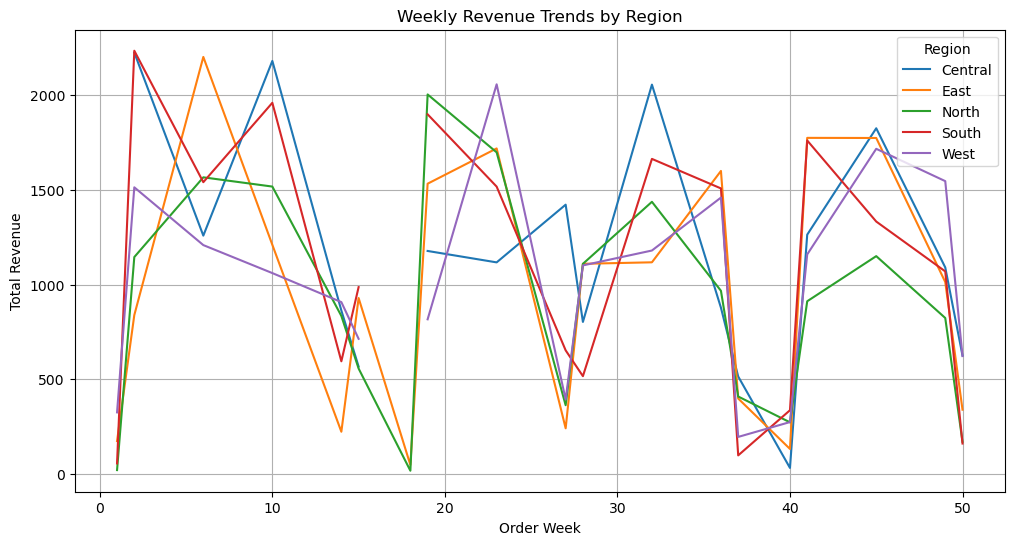

In [74]:
# Line Plot – Weekly Revenue Trends by Region
import matplotlib.pyplot as plt

weekly_revenue_pivot.plot(figsize=(12,6))

plt.title('Weekly Revenue Trends by Region')
plt.xlabel('Order Week')
plt.ylabel('Total Revenue')
plt.legend(title='Region')
plt.grid(True)
plt.show()

In [75]:
#Product category performance (revenue, quantity, discount)
category_performance = (
    merged_df
    .groupby('category')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_quantity=('quantity', 'sum'),
        avg_discount=('discount_applied', 'mean')
    )
    .sort_values(by='total_revenue', ascending=False)
)

category_performance

,total_revenue,total_quantity,avg_discount
category,,,
Cleaning,93567.9475,3581.0,0.085595
Storage,46931.4575,1730.0,0.081043
Outdoors,40062.0680,1519.0,0.082016
Kitchen,33933.6760,1226.0,0.075622
Personal Care,24892.2765,900.0,0.087043


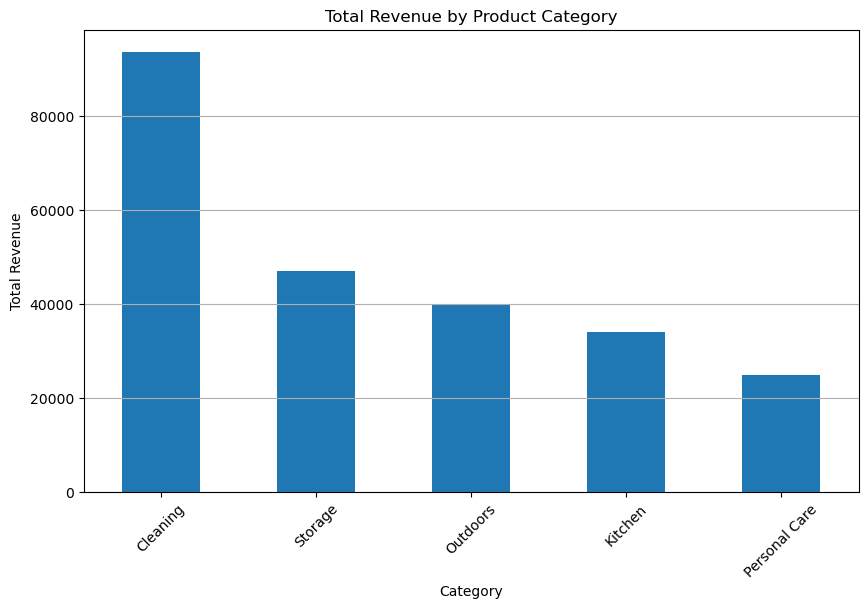

In [80]:
#Top 5 Categories

category_performance['total_revenue'].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Total Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [81]:
#checking correalation
merged_df[['quantity','discount_applied']].corr()

,quantity,discount_applied
quantity,1.000000,-0.011994
discount_applied,-0.011994,1.000000


In [84]:
# creating discount groups
merged_df['discount_group'] = pd.cut(
    merged_df['discount_applied'],
    bins=[0, 0.05, 0.10, 0.20, 1],
    labels=['0-5%','5-10%','10-20%','20%+']
)

In [87]:
merged_df.groupby('discount_group', observed=False)['quantity'].mean()

discount_group
0-5%      3.085828
5-10%     2.982213
10-20%    2.968560
20%+           NaN
Name: quantity, dtype: float64

In [90]:
# Average Revenue by Discount Group
discount_revenue = (
    merged_df
    .groupby('discount_group', observed=False)['revenue']
    .mean()
)

discount_revenue

discount_group
0-5%      87.032439
5-10%     77.655202
10-20%    71.802598
20%+            NaN
Name: revenue, dtype: float64

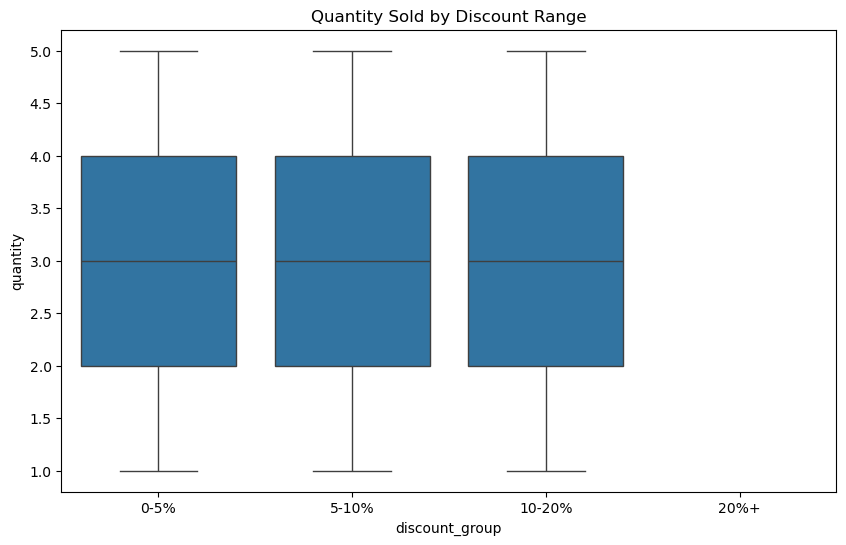

In [91]:
#Visualising Relationship (Boxplot)
import seaborn as sns

plt.figure(figsize=(10,6))

merged_df['discount_group'] = pd.cut(
    merged_df['discount_applied'],
    bins=[0, 0.05, 0.10, 0.20, 1],
    labels=['0-5%','5-10%','10-20%','20%+']
)

sns.boxplot(
    x='discount_group',
    y='quantity',
    data=merged_df
)

plt.title('Quantity Sold by Discount Range')
plt.show()

In [92]:
# Customer behaviour by loyalty_tier and signup_month
# Loyalty Performance Table
loyalty_analysis = (
    merged_df
    .groupby('loyalty_tier')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_quantity=('quantity', 'sum'),
        avg_revenue=('revenue', 'mean'),
        order_count=('order_id', 'count')
    )
    .sort_values(by='total_revenue', ascending=False)
)

loyalty_analysis

,total_revenue,total_quantity,avg_revenue,order_count
loyalty_tier,,,,
Gold,135092.1610,4984.0,81.528160,1657
Silver,51255.2485,1944.0,78.733101,651
Bronze,48281.5225,1840.0,78.634401,613
Unknown,2092.6190,99.0,63.412697,33
Gld,1084.9690,36.0,83.459154,13
Brnze,803.5460,24.0,73.049636,11
Sllver,777.3595,29.0,129.559917,6


In [93]:
# fixing Loyalty Tier

merged_df['loyalty_tier'] = merged_df['loyalty_tier'].replace({
    'Gld': 'Gold',
    'Brnze': 'Bronze',
    'Sllver': 'Silver'
})

In [94]:
#recalculation
loyalty_analysis = (
    merged_df
    .groupby('loyalty_tier')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_quantity=('quantity', 'sum'),
        avg_revenue=('revenue', 'mean'),
        order_count=('order_id', 'count')
    )
    .sort_values(by='total_revenue', ascending=False)
)

loyalty_analysis

,total_revenue,total_quantity,avg_revenue,order_count
loyalty_tier,,,,
Gold,136177.1300,5020.0,81.543192,1670
Silver,52032.6080,1973.0,79.197272,657
Bronze,49085.0685,1864.0,78.536110,624
Unknown,2092.6190,99.0,63.412697,33


In [95]:
# create sign up month 
merged_df['signup_month'] = merged_df['signup_date'].dt.month

AttributeError: Can only use .dt accessor with datetimelike values

In [96]:
merged_df['signup_date'].dtype


dtype('O')

In [97]:
merged_df['signup_date'] = pd.to_datetime(
    merged_df['signup_date'],
    errors='coerce'
)

C:\Users\mon12\AppData\Local\Temp\ipykernel_19532\2120557956.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['signup_date'] = pd.to_datetime(


In [98]:
merged_df['signup_date'].dtype

dtype('<M8[ns]')

In [99]:
merged_df['signup_month'] = merged_df['signup_date'].dt.strftime('%b')

In [100]:
# Creating Signup Month
signup_analysis = (
    merged_df
    .groupby(['signup_month', 'loyalty_tier'])
    .size()
    .unstack(fill_value=0)
)

signup_analysis

loyalty_tier,Bronze,Gold,Silver,Unknown
signup_month,,,,
Apr,28,145,69,0
Aug,49,147,47,0
Dec,59,150,23,0
Feb,61,111,53,6
Jan,40,136,52,0
Jul,47,129,34,0
Jun,81,101,64,0
Mar,57,95,83,0
May,41,112,54,3


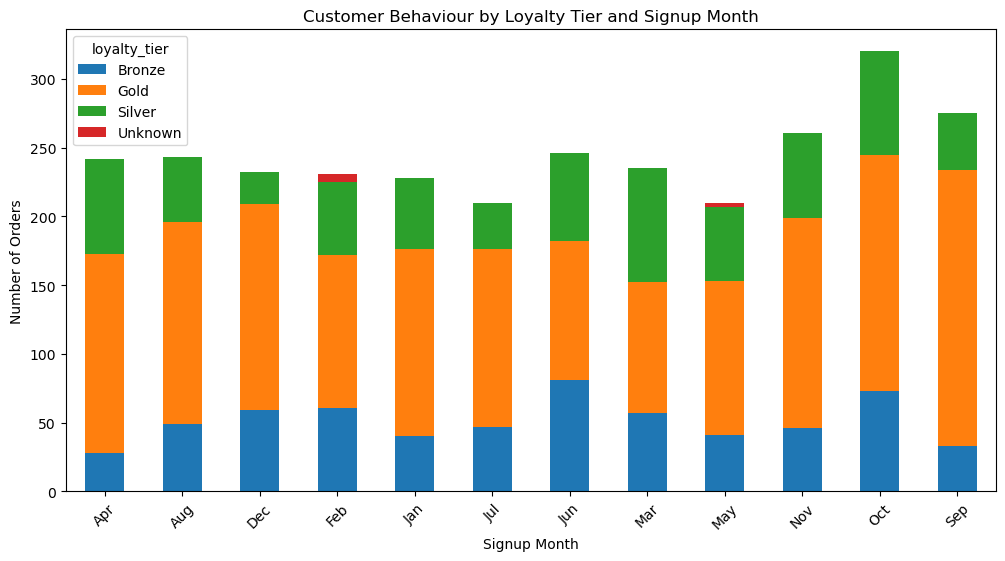

In [101]:
# stack bar chart for analysis
signup_analysis.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Customer Behaviour by Loyalty Tier and Signup Month")
plt.xlabel("Signup Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [102]:
# (stretched task)Creating Delivery Summary Table
delivery_analysis = (
    merged_df
    .groupby(['sales_region', 'price_band'])
    .agg(
        total_orders=('order_id', 'count'),
        delayed_orders=('is_late', 'sum')
    )
)

delivery_analysis['delay_rate'] = (
    delivery_analysis['delayed_orders'] /
    delivery_analysis['total_orders']
)

delivery_analysis = delivery_analysis.sort_values(by='delay_rate', ascending=False)

delivery_analysis

C:\Users\mon12\AppData\Local\Temp\ipykernel_19532\4166215849.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['sales_region', 'price_band'])


total_orders  delayed_orders  delay_rate
sales_region price_band                                          
North        Medium               203              89    0.438424
East         Medium               236             100    0.423729
South        High                 294             124    0.421769
East         Low                   96              40    0.416667
             High                 266             109    0.409774
Central      High                 264             104    0.393939
             Medium               225              88    0.391111
West         Low                   77              30    0.389610
             High                 268             103    0.384328
Central      Low                  112              43    0.383929
North        Low                  107              41    0.383178
             High                 293             106    0.361775
South        Medium               202              73    0.361386
West         Medium               243              85    0.349794
South        Low                   97              32    0.329897
Nrth         Medium                 1               0    0.000000
             Low                    0               0         NaN
             High                   0               0         NaN

In [103]:
# fixing values
merged_df['sales_region'] = merged_df['sales_region'].replace({
    'Nrth': 'North'
})

In [104]:
# recalculation
delivery_analysis = (
    merged_df
    .groupby(['sales_region', 'price_band'])
    .agg(
        total_orders=('order_id', 'count'),
        delayed_orders=('is_late', 'sum')
    )
)

delivery_analysis['delay_rate'] = (
    delivery_analysis['delayed_orders'] /
    delivery_analysis['total_orders']
)

delivery_analysis = delivery_analysis.sort_values(by='delay_rate', ascending=False)

delivery_analysis


C:\Users\mon12\AppData\Local\Temp\ipykernel_19532\1688265199.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['sales_region', 'price_band'])


total_orders  delayed_orders  delay_rate
sales_region price_band                                          
North        Medium               204              89    0.436275
East         Medium               236             100    0.423729
South        High                 294             124    0.421769
East         Low                   96              40    0.416667
             High                 266             109    0.409774
Central      High                 264             104    0.393939
             Medium               225              88    0.391111
West         Low                   77              30    0.389610
             High                 268             103    0.384328
Central      Low                  112              43    0.383929
North        Low                  107              41    0.383178
             High                 293             106    0.361775
South        Medium               202              73    0.361386
West         Medium               243              85    0.349794
South        Low                   97              32    0.329897

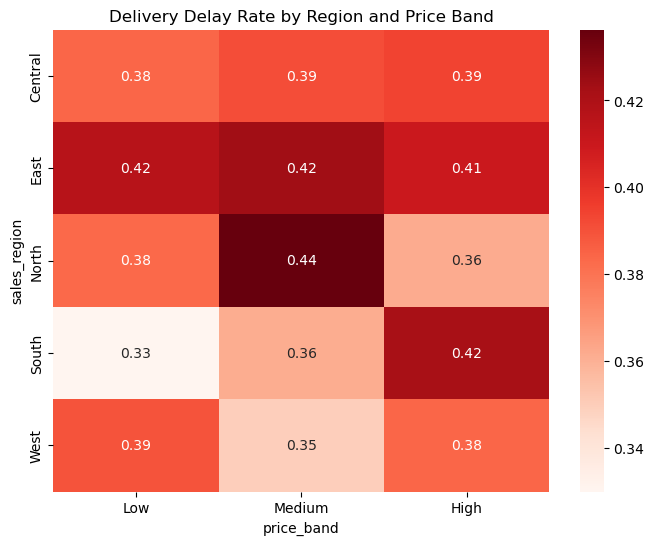

In [105]:
# creating visuals
delay_pivot = delivery_analysis.reset_index().pivot(
    index='sales_region',
    columns='price_band',
    values='delay_rate'
)

plt.figure(figsize=(8,6))
sns.heatmap(delay_pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title("Delivery Delay Rate by Region and Price Band")
plt.show()

In [114]:
#Preferred Payment Methods by Loyalty Tier
payment_analysis = (
    merged_df
    .groupby(['loyalty_tier', 'payment_method'])
    .size()
    .unstack(fill_value=0)
)

payment_analysis

payment_method,Bank Transfer,Credit Card,Paypal
loyalty_tier,,,
Bronze,178,284,163
Gold,403,839,426
Silver,190,304,162
Unknown,4,22,7


In [116]:
merged_df['payment_method'] = merged_df['payment_method'].replace({
    'Bank Transfr': 'Bank Transfer'
})

In [117]:
#recalculation
payment_percentage = (
    payment_analysis.div(payment_analysis.sum(axis=1), axis=0)
)

payment_percentage

payment_method,Bank Transfer,Credit Card,Paypal
loyalty_tier,,,
Bronze,0.284800,0.454400,0.260800
Gold,0.241607,0.502998,0.255396
Silver,0.289634,0.463415,0.246951
Unknown,0.121212,0.666667,0.212121


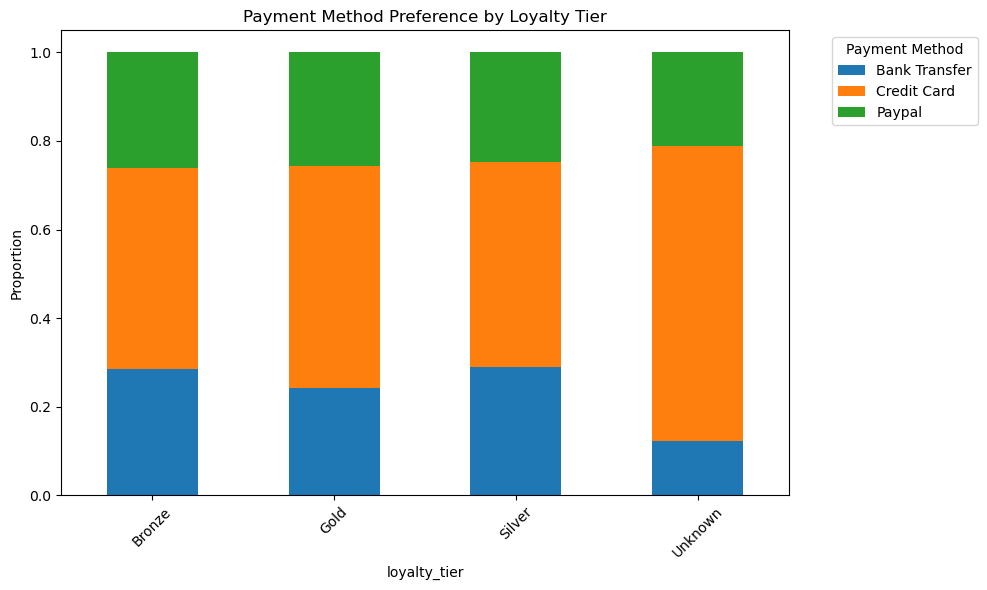

In [119]:
# visualising the percentage in stacked bar
payment_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Payment Method Preference by Loyalty Tier")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.legend(
    title="Payment Method",
    bbox_to_anchor=(1.05, 1),   # Move outside
    loc='upper left'
)

plt.tight_layout()
plt.show()

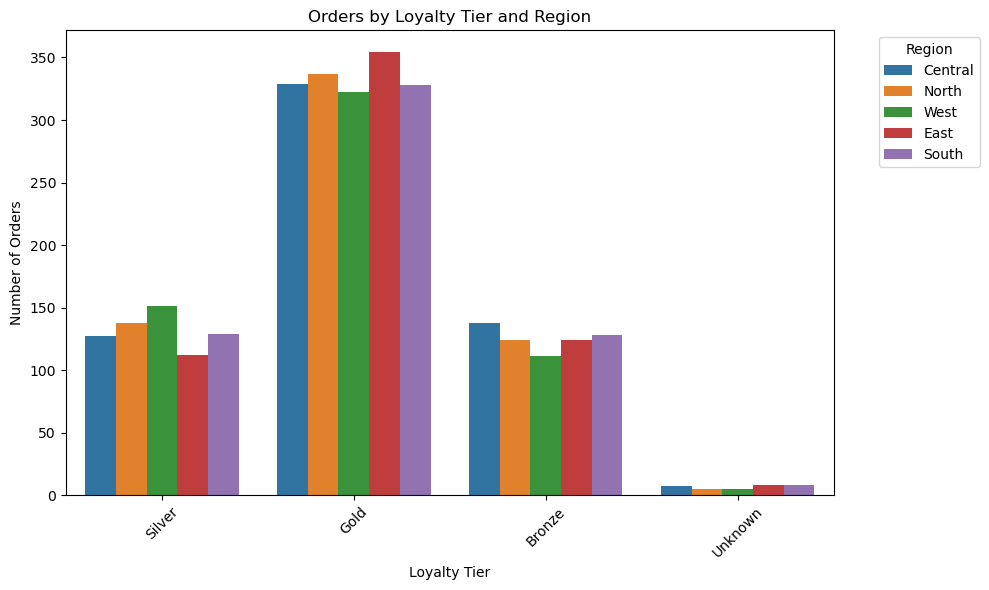

In [120]:
# Countplot - orders by loyalty tier (with hue = region)
plt.figure(figsize=(10,6))

sns.countplot(
    data=merged_df,
    x='loyalty_tier',
    hue='sales_region'
)

plt.title('Orders by Loyalty Tier and Region')
plt.xlabel('Loyalty Tier')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()